# M1 練習 Notebook — Pandas 時序資料探索

本 notebook 分兩部分：
- **Part A（Mentor 示範）**：常用 API 的函式簽名 + 操作範例
- **Part B（你來練習）**：空格讓你舉一反三，熟悉 API 語法

資料集：Microsoft Azure Predictive Maintenance（5 張表）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

---
# Part A — Mentor 示範
---

## A1. 讀取 CSV

```python
pd.read_csv(
    filepath,
    parse_dates=[col, ...],   # 直接把指定欄位轉成 datetime64
    dtype={col: type, ...},   # 指定欄位型別，省去後續轉換
    usecols=[col, ...],       # 只讀需要的欄位，省記憶體
)
```

In [5]:
# 示範：讀取 telemetry，並讓 datetime 欄位直接是 datetime 型別
telemetry = pd.read_csv('../data/raw/PdM_telemetry.csv', parse_dates=['datetime'])
print(telemetry.dtypes)
print(telemetry.shape)

datetime     datetime64[ns]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
dtype: object
(876100, 6)


In [6]:
# 示範：只讀需要的欄位
tele_slim = pd.read_csv('../data/raw/PdM_telemetry.csv',
                         parse_dates=['datetime'],
                         usecols=['datetime', 'machineID', 'volt'])
print(tele_slim.columns.tolist())

['datetime', 'machineID', 'volt']


## A2. 快速掌握 DataFrame 樣貌

```python
df.shape                  # (rows, cols)
df.dtypes                 # 每欄的型別
df.head(n)                # 前 n 筆，預設 5
df.tail(n)                # 後 n 筆
df.describe()             # 數值欄的統計摘要（count, mean, std, min, 25%, 50%, 75%, max）
df.info()                 # 欄位型別 + 非空值數量 + 記憶體用量
df.isnull().sum()         # 每欄缺值數量
df['col'].value_counts()  # 類別欄的頻次統計
df['col'].nunique()       # 不重複值的數量
```

In [7]:
# 示範：errors 表快速摘要
errors = pd.read_csv('../data/raw/PdM_errors.csv', parse_dates=['datetime'])

print('shape:', errors.shape)
print()
print('dtypes:')
print(errors.dtypes)
print()
print('缺值：')
print(errors.isnull().sum())
print()
print('errorID 頻次：')
print(errors['errorID'].value_counts())

shape: (3919, 3)

dtypes:
datetime     datetime64[ns]
machineID             int64
errorID              object
dtype: object

缺值：
datetime     0
machineID    0
errorID      0
dtype: int64

errorID 頻次：
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64


In [12]:
print(errors.isnull().sum())

datetime     0
machineID    0
errorID      0
dtype: int64


In [14]:
print(telemetry.head())

             datetime  machineID    volt  rotate  pressure  vibration  month
0 2015-01-01 06:00:00          1 176.218 418.504   113.078     45.088      1
1 2015-01-01 07:00:00          1 162.879 402.747    95.461     43.414      1
2 2015-01-01 08:00:00          1 170.990 527.350    75.238     34.179      1
3 2015-01-01 09:00:00          1 162.463 346.149   109.249     41.122      1
4 2015-01-01 10:00:00          1 157.610 435.377   111.887     25.991      1


## A3. 時間欄位操作（`.dt` accessor）

當欄位型別是 `datetime64` 時，可以用 `.dt` 存取各種時間屬性：

```python
df['datetime'].dt.year        # 年
df['datetime'].dt.month       # 月
df['datetime'].dt.dayofweek   # 星期幾（0=週一）
df['datetime'].dt.hour        # 小時
df['datetime'].dt.date        # 只取日期部分（回傳 Python date object）

df['datetime'].min()          # 最早時間
df['datetime'].max()          # 最晚時間
df['datetime'].diff()         # 相鄰兩筆的時間差（回傳 Timedelta Series）
```

In [13]:
# 示範：telemetry 時間軸的起點、終點，以及取出月份欄位
print('起點：', telemetry['datetime'].min())
print('終點：', telemetry['datetime'].max())

# 加一個月份欄位
telemetry['month'] = telemetry['datetime'].dt.month
print(telemetry[['datetime', 'month']].head(3))

起點： 2015-01-01 06:00:00
終點： 2016-01-01 06:00:00
             datetime  month
0 2015-01-01 06:00:00      1
1 2015-01-01 07:00:00      1
2 2015-01-01 08:00:00      1


In [20]:
m1 = telemetry[telemetry['machineID'] == 1].sort_values('datetime')
diffs = m1['datetime'].diff()
print(diffs.value_counts())

datetime
0 days 01:00:00    8760
Name: count, dtype: int64


In [18]:
# 示範：確認 telemetry 的時間頻率是否真的是每小時
# .diff() 計算相鄰兩筆的時間差，.dt.total_seconds() 轉成秒
m1 = telemetry[telemetry['machineID'] == 1].sort_values('datetime')
diffs = m1['datetime'].diff().dropna().dt.total_seconds() / 3600  # 轉成小時
print('時間間隔頻次：')
print(diffs.value_counts())

時間間隔頻次：
datetime
1.000    8760
Name: count, dtype: int64


## A4. 篩選（Boolean Masking）

```python
df[df['col'] == value]                      # 等於
df[df['col'].isin([v1, v2])]               # 在清單內
df[(condition1) & (condition2)]             # AND（注意要加括號）
df[(condition1) | (condition2)]             # OR
df[df['datetime'] >= '2015-06-01']         # 時間篩選（字串會自動轉換）
df[df['datetime'].between(start, end)]      # 時間區間
```

In [21]:
# 示範：取出 machine 3 在 2015 年 3 月的 telemetry
mask = (
    (telemetry['machineID'] == 3) &
    (telemetry['datetime'].dt.year == 2015) &
    (telemetry['datetime'].dt.month == 3)
)
subset = telemetry[mask]
print(f'筆數：{len(subset)}')
print(subset.head(3))

筆數：744
                 datetime  machineID    volt  rotate  pressure  vibration  \
18932 2015-03-01 00:00:00          3 159.477 467.049   101.129     44.775   
18933 2015-03-01 01:00:00          3 186.803 506.899   113.277     39.645   
18934 2015-03-01 02:00:00          3 160.101 507.085    95.821     47.515   

       month  
18932      3  
18933      3  
18934      3  


## A5. 分組聚合（groupby）

```python
df.groupby('col').size()                    # 每組筆數
df.groupby('col')['num_col'].mean()         # 每組某欄的平均
df.groupby('col')['num_col'].agg(['mean', 'std', 'max'])  # 多個聚合
df.groupby(['col1', 'col2']).size()         # 多欄分組
```

In [28]:
# 示範：每台機器的 volt 平均值與標準差
volt_stats = telemetry.groupby('machineID')['volt'].agg(['mean', 'std'])
print(volt_stats.head(5))

             mean    std
machineID               
1         170.834 15.314
2         170.760 15.537
3         170.659 15.380
4         170.660 15.465
5         171.044 15.547


In [ ]:
# 示範：每台機器的資料筆數（確認資料完整性）
counts = telemetry.groupby('machineID').size()

print(counts.head())

print(f'最少：{counts.min()}，最多：{counts.max()}，平均：{counts.mean():.0f}')

machineID
1    8761
2    8761
3    8761
4    8761
5    8761
dtype: int64
最少：8761，最多：8761，平均：8761


## A6. Resample — 時序重採樣

`resample` 是 pandas 專為時序資料設計的 groupby，以時間頻率為分組依據。

```python
# 必須先 set_index 成 datetime，或用 on= 指定欄位
df.set_index('datetime').resample('h').mean()    # 每小時平均
df.set_index('datetime').resample('D').sum()     # 每日加總
df.set_index('datetime').resample('ME').size()   # 每月筆數（ME = month end）
df.set_index('datetime').resample('W').mean()    # 每週平均
```

常見頻率字串：`'h'`（小時）、`'D'`（天）、`'W'`（週）、`'ME'`（月底）、`'YE'`（年底）

In [75]:
# 示範：每月的故障事件數
failures = pd.read_csv('../data/raw/PdM_failures.csv', parse_dates=['datetime'])

monthly_failures = failures.set_index('datetime').resample('ME')

In [45]:
# 示範：machine 1 的 volt 每日平均
m1_daily_volt = (
    telemetry[telemetry['machineID'] == 1]
    .set_index('datetime')['volt']
    .resample('D').mean()
)
print(m1_daily_volt.head(7))

datetime
2015-01-01   167.577
2015-01-02   169.796
2015-01-03   171.862
2015-01-04   174.792
2015-01-05   171.018
2015-01-06   171.025
2015-01-07   174.139
Freq: D, Name: volt, dtype: float64


## A7. Merge — 表格合併

```python
pd.merge(left, right, on='key', how='inner')   # 內連接：只保留兩邊都有的 key
pd.merge(left, right, on='key', how='left')    # 左連接：保留左表所有列
pd.merge(left, right, on=['k1','k2'], how='left')  # 多欄 key

# 當兩表有同名欄位（非 key），pandas 會自動加後綴區分
pd.merge(left, right, on='key', suffixes=('_left', '_right'))
```

In [46]:
# 示範：把 machines（靜態資訊）join 進 telemetry
machines = pd.read_csv('../data/raw/PdM_machines.csv')

tele_with_meta = pd.merge(telemetry, machines, on='machineID', how='left')
print(tele_with_meta.columns.tolist())
print(tele_with_meta.head(3))

['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'month', 'model', 'age']
             datetime  machineID    volt  rotate  pressure  vibration  month  \
0 2015-01-01 06:00:00          1 176.218 418.504   113.078     45.088      1   
1 2015-01-01 07:00:00          1 162.879 402.747    95.461     43.414      1   
2 2015-01-01 08:00:00          1 170.990 527.350    75.238     34.179      1   

    model  age  
0  model3   18  
1  model3   18  
2  model3   18  


---
# Part B — 你來練習

以下每個 cell 都有題目，你在 `# TODO` 的地方填入程式碼。
不要看上面的示範直接抄，先想一下 API 的用法再寫。

---

## B1. 讀取剩下的 3 張表

用 `pd.read_csv` 載入 `PdM_maint.csv` 和 `PdM_failures.csv`（datetime 欄要是 datetime 型別），
以及 `PdM_machines.csv`（沒有 datetime 欄）。
印出每張表的 shape 和 dtypes。

In [ ]:
# TODO: 讀取 maint, failures, machines
from pathlib import Path

data_dir = Path('../data/raw')

maint = pd.read_csv(data_dir / 'PdM_maint.csv', parse_dates=['datetime'])
failures = pd.read_csv(data_dir / 'PdM_failures.csv', parse_dates=['datetime'])
machines = pd.read_csv(data_dir / 'PdM_machines.csv')

# TODO: 印出每張表的 shape 和 dtypes
loop = [('maint', maint), ('failures', failures), ('machines', machines)]

for name , df in loop:
    print(f'{name} shape : {df.shape}')
    print(f'{name} dtypes :')
    print(df.dtypes)

maint shape : (3286, 3)
maint dtypes :
datetime     datetime64[ns]
machineID             int64
comp                 object
dtype: object
failures shape : (761, 3)
failures dtypes :
datetime     datetime64[ns]
machineID             int64
failure              object
dtype: object
machines shape : (100, 3)
machines dtypes :
machineID     int64
model        object
age           int64
dtype: object


## B2. 時間範圍確認

印出 telemetry、errors、maint、failures 四張表的時間起點和終點。
格式：`{表名}: {min}  →  {max}`

In [50]:
# TODO
loop =[("telemetry", telemetry), ("errors", errors),("maint", maint), ("failures", failures)]

for name, df in loop:
    print(f"{name}: {df['datetime'].min()} -> {df['datetime'].max()}")


telemetry: 2015-01-01 06:00:00 -> 2016-01-01 06:00:00
errors: 2015-01-01 06:00:00 -> 2016-01-01 05:00:00
maint: 2014-06-01 06:00:00 -> 2016-01-01 06:00:00
failures: 2015-01-02 03:00:00 -> 2015-12-31 06:00:00


## B3. 正負樣本比例

Telemetry 有幾筆？Failures 有幾筆？
如果直接用「那個小時有沒有 failure」當 label，正樣本比例是多少？
（提示：不需要真的做 label，只要算比例）

In [74]:
# TODO
tele_size = telemetry.shape[0]
print(f"telemetry 總共有 {tele_size} 筆資料")

failures_size = failures.shape[0]
print(f"failures 總共有 {failures_size} 筆資料")

failures_hourly = failures.set_index('datetime').resample('h')

print(failures.shape[0])

print(failures_hourly.size().mean())

telemetry 總共有 876100 筆資料
failures 總共有 761 筆資料
761
0.08731069297843047


In [73]:
tele_count = telemetry.shape[0]
fail_count = failures.shape[0]

ratio = fail_count / tele_count
print(f'Telemetry 筆數：{tele_count}')
print(f'Failures 筆數：{fail_count}')
print(f'正樣本比例：{ratio:.4f}')


Telemetry 筆數：876100
Failures 筆數：761
正樣本比例：0.0009


In [90]:
a= failures.set_index('datetime').resample('h').size()
print(a.dtype)

b = (failures.set_index('datetime').resample('h').size() == 18)
print(b)

int64
datetime
2015-01-02 03:00:00     True
2015-01-02 04:00:00    False
2015-01-02 05:00:00    False
2015-01-02 06:00:00    False
2015-01-02 07:00:00    False
                       ...  
2015-12-31 02:00:00    False
2015-12-31 03:00:00    False
2015-12-31 04:00:00    False
2015-12-31 05:00:00    False
2015-12-31 06:00:00    False
Freq: h, Length: 8716, dtype: bool


## B4. 每台機器的故障次數

用 `failures` 表，計算每台機器的故障次數（按次數由高到低排序）。
印出前 10 名。

In [97]:
# TODO


c = failures.groupby('machineID').size()
print(c.sort_values(ascending=False).head(10))

machineID
99    19
98    16
22    15
17    15
83    14
37    14
20    13
13    13
16    13
71    13
dtype: int64


## B5. 篩選 + 時間操作

取出 machine 5 在 2015 年第二季（4月、5月、6月）的 errors 紀錄，
印出總筆數和每種 errorID 各出現幾次。

In [105]:
errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [115]:
# TODO

mask = (errors['machineID'] == 5) & (errors['datetime'].dt.month.isin([4,5,6]))

c = errors[mask]
print(c.shape[0])


c['errorID'].value_counts()

10


errorID
error1    4
error3    3
error5    1
error4    1
error2    1
Name: count, dtype: int64

## B6. Resample 練習

計算所有機器的 telemetry，**以週為單位**，每週的 `vibration` 平均值。
印出前 8 週的結果。

In [123]:
# TODO
c = telemetry.set_index('datetime')['vibration'].resample('W').mean()
c.head(8)

datetime
2015-01-04   40.620
2015-01-11   40.208
2015-01-18   40.400
2015-01-25   40.339
2015-02-01   40.300
2015-02-08   40.449
2015-02-15   40.197
2015-02-22   40.408
Freq: W-SUN, Name: vibration, dtype: float64

In [125]:
telemetry.groupby('machineID').resample('W', on='datetime')['vibration']


## B7. 自由探索（開放題）

選一台你好奇的機器（不要選 machine 1，已經被示範過了），
找出它的第一次故障時間，然後觀察故障前 48 小時的感測器數值變化。
畫一張折線圖（4 個感測器都畫進去）。

In [157]:
# TODO
failures = pd.read_csv('../data/raw/PdM_failures.csv', parse_dates=['datetime'])
telemetry = pd.read_csv('../data/raw/PdM_telemetry.csv', parse_dates=['datetime'])

c = failures[failures["machineID"] == 2]


earliest_failure = c['datetime'].min()
print(f'最早的故障事件發生在 {earliest_failure}')


c
print(earliest_failure)



最早的故障事件發生在 2015-03-19 06:00:00
2015-03-19 06:00:00


In [160]:
start = earliest_failure - pd.Timedelta(hours=48)
print(f'48 小時前的時間點是 {start}')

48 小時前的時間點是 2015-03-17 06:00:00


In [162]:
d = telemetry[telemetry['machineID'] == 2]

mask = (d['datetime'] >= start) & (d['datetime'] <= earliest_failure)

last48hours = d[mask]

last48hours

,datetime,machineID,volt,rotate,pressure,vibration
10561,2015-03-17 06:00:00,2,192.712,321.624,99.035,49.729
10562,2015-03-17 07:00:00,2,207.277,408.236,104.339,36.297
10563,2015-03-17 08:00:00,2,175.644,383.295,84.842,39.054
10564,2015-03-17 09:00:00,2,201.348,353.124,97.750,40.655
10565,2015-03-17 10:00:00,2,161.933,441.431,101.193,48.863
10566,2015-03-17 11:00:00,2,184.104,327.363,114.519,42.388
10567,2015-03-17 12:00:00,2,189.320,382.946,125.161,49.316
10568,2015-03-17 13:00:00,2,227.782,381.316,85.974,36.072
10569,2015-03-17 14:00:00,2,200.629,446.249,86.729,48.102
10570,2015-03-17 15:00:00,2,183.856,291.094,115.509,35.064


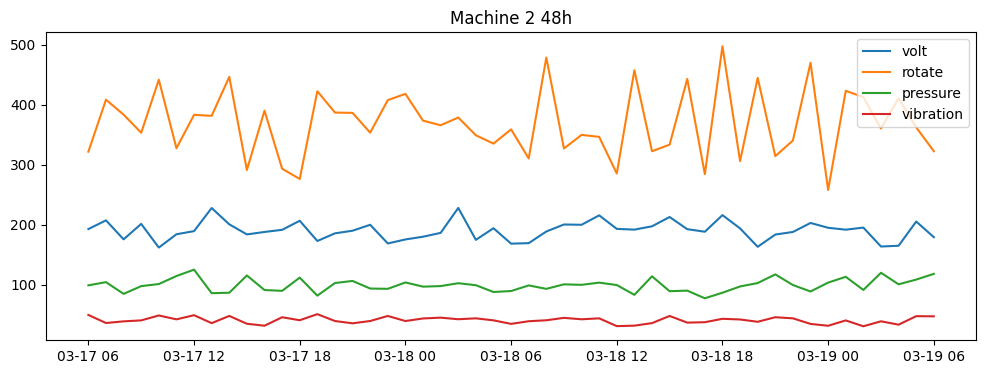

In [164]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(last48hours['datetime'], last48hours['volt'], label='volt')
ax.plot(last48hours['datetime'], last48hours['rotate'], label='rotate')
ax.plot(last48hours['datetime'], last48hours['pressure'], label='pressure')
ax.plot(last48hours['datetime'], last48hours['vibration'], label='vibration')

ax.legend()
ax.set_title('Machine 2 48h')
plt.show()
